In [355]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import airy
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

In [356]:
#CONSTANTS
c = 299792458.0
e = 1.60217663e-19
h = 6.62607015e-34
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895

In [357]:
#ENERGY PARAMETERS
E_MeV = 100
E_total = E_MeV + m_e_MeV
gamma = E_total / m_e_MeV
beta = np.sqrt(1 - 1 / gamma**2)
v = beta * c
lam_e = (h * c)/ E_MeV

In [358]:
#ARES CHARGE PARAMETERS
bunchcharge = 5e-12
Ne = bunchcharge/e

In [359]:
# BEAM PARAMETERS - OAM + GAUSSIAN
sigma_x = 100e-6
sigma_y = 100e-6  # 100 µm

In [360]:
#TEMPORAL PULSE (in sec)
sigma_t = 1e-12

In [361]:
#SIGMA Z FOR GAUSSIAN
sigma_z = c*sigma_t

In [362]:
#OBSERVATION GRIDS
Nangle, Nlam = 500, 500
th = np.linspace(-0.2, 0.2, Nangle)
lam = np.linspace(1e-6,1e-5, Nlam)
# lam = np.logspace(-6, -3, Nlam)  # 1 µm to 1000 µm
phi = np.linspace(0, 2*np.pi, Nangle)
LAM, TH, PHI = np.meshgrid(lam, th, phi, indexing='ij')
OMEGA = 2*np.pi*c/LAM

In [363]:
# #SINGLE ELECTRON SPECTRUM
A = e**2 / (4*np.pi * eps0 * c)
W1 = A*(beta**2 * np.sin(TH)**2) / (1.0 - beta**2 * np.cos(TH)**2)**2

In [364]:
x = np.linspace(-5*sigma_x, 5*sigma_x, 500)
y = np.linspace(-5*sigma_y, 5*sigma_y, 500)
z = np.linspace(-5*sigma_z, 5*sigma_z, 500)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

In [365]:
#3D GAUSSIAN DIST
exponent = -(X**2 / (2 * sigma_x**2) + Y**2 / (2 * sigma_y**2) + Z**2 / (2 * sigma_z**2))
rho_gaussian = np.exp(exponent)

In [366]:
rho_gaussian.shape #-> x, y, and z

(500, 500, 500)

In [367]:
#BUILDING OAM DIST
r2 = X**2 + Y**2
ell = 5
rho_oam = ((r2 / sigma_x**2)**abs(ell) * np.exp(-r2 / (2 * sigma_y**2)) * np.exp(-Z**2 / (2 * sigma_z**2)))

In [368]:
#BUILDING AIRY DIST
k_B = 2*np.pi/(lam_e)
Ai_x = airy(X / sigma_x - z**2 / (4 * k_B**2 * sigma_x**4))[0]
Ai_y = airy(Y / sigma_y - z**2 / (4 * k_B**2 * sigma_y**4))[0]
phase_x = np.exp(1j * X * Z / (2 * k_B * sigma_x**3) - 1j * Z**3 / (12 * k_B**3 * sigma_x**6))
phase_y = np.exp(1j * Y * Z / (2 * k_B * sigma_y**3) - 1j * Z**3 / (12 * k_B**3 * sigma_y**6))

psi_airy = Ai_x * Ai_y * phase_x * phase_y
rho_airy = np.abs(psi_airy)**2

In [369]:
def f2_3d(omega, theta, phi, rho_xyz, x, y, z, beta):

    omega = np.asarray(omega, dtype=float)
    theta = np.asarray(theta, dtype=float)
    phi = np.asarray(phi, dtype=float)
    rho_xyz = np.asarray(rho_xyz, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    rho_x = np.trapezoid(np.trapezoid(rho_xyz, z, axis=2), y, axis=1)
    rho_y = np.trapezoid(np.trapezoid(rho_xyz, z, axis=2), x, axis=0)
    rho_z = np.trapezoid(np.trapezoid(rho_xyz, y, axis=1), x, axis=0)

    rho_x /= np.trapezoid(rho_x, x)
    rho_y /= np.trapezoid(rho_y, y)
    rho_z /= np.trapezoid(rho_z, z)

    R_x = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho_x))) * dx
    R_y = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho_y))) * dy
    R_z = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho_z))) * dz

    kx = np.fft.fftshift(2*np.pi*np.fft.fftfreq(x.size, d=dx))
    ky = np.fft.fftshift(2*np.pi*np.fft.fftfreq(y.size, d=dy))
    kz = np.fft.fftshift(2*np.pi*np.fft.fftfreq(z.size, d=dz))

    #Normalize
    R_x /= R_x[np.argmin(np.abs(kx))]
    R_y /= R_y[np.argmin(np.abs(ky))]
    R_z /= R_z[np.argmin(np.abs(kz))]

    K = omega / c
    kx_target = K * np.sin(theta) * np.cos(phi)
    ky_target = K * np.sin(theta) * np.sin(phi)
    kz_target = K * (1.0 / beta - np.cos(theta))

    #Values outside the sampled FFT range are set to zero rather than clipped
    F2_x = np.interp(kx_target.ravel(), kx, np.abs(R_x)**2, left=0.0, right=0.0).reshape(kx_target.shape)
    F2_y = np.interp(ky_target.ravel(), ky, np.abs(R_y)**2, left=0.0, right=0.0).reshape(ky_target.shape)
    F2_z = np.interp(kz_target.ravel(), kz, np.abs(R_z)**2, left=0.0, right=0.0).reshape(kz_target.shape)

    return np.clip(F2_x * F2_y * F2_z, 0.0, 1.0)

In [370]:
# CALCULATING BUNCH SPECTRUM
def electron_bunch_spectrum(W1, Ne, omega, theta, phi, rho_xyz, x, y, z, beta):
    F2 = f2_3d(omega, theta, phi, rho_xyz, x, y, z, beta)
    Wn = W1 * (Ne + Ne * (Ne - 1) * F2)

    positive = Wn[Wn > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = np.max(Wn)

    return [Wn], vmin, vmax, F2


In [371]:
Wn_list_gaussian, vmin_gaussian, vmax_gaussian, F2_gaussian = electron_bunch_spectrum(W1, Ne, OMEGA, TH, PHI, rho_gaussian, x, y, z, beta)
Wn_list_oam, vmin_oam, vmax_oam, F2_oam = electron_bunch_spectrum(W1, Ne, OMEGA, TH, PHI, rho_oam, x, y, z, beta)
Wn_list_airy, vmin_airy, vmax_airy, F2_airy = electron_bunch_spectrum(W1, Ne, OMEGA, TH, PHI, rho_airy, x, y, z, beta)

In [372]:
# Integrate over phi to obtain a 2D (lambda, theta) spectrum.
Wn_2d_gaussian = np.trapezoid(Wn_list_gaussian[0], phi, axis=2)
Wn_2d_oam = np.trapezoid(Wn_list_oam[0], phi, axis=2)
Wn_2d_airy = np.trapezoid(Wn_list_airy[0], phi, axis=2)

In [373]:
def plot_ctr_spectrum(th, lam, Wn_2d, vmin=None, vmax=None, sigma_t=None):
    Wn_2d = np.asarray(Wn_2d)

    expected_shape = (lam.size, th.size)
    if Wn_2d.shape != expected_shape:
        raise ValueError(
            f"Wn_2d has shape {Wn_2d.shape}; expected {expected_shape}. "
            "Integrate the 3D spectrum over phi first."
        )

    fig, ax = plt.subplots()

    im = ax.pcolormesh(th, lam * 1e6, np.maximum(Wn_2d, vmin), shading='auto', cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax), rasterized=True)
    # im = ax.pcolormesh(th, lam * 1e6, np.maximum(Wn_2d, vmin), shading='auto', cmap='plasma', rasterized=True)
    if sigma_t is None:
        ax.set_title("CTR")
    else:
        ax.set_title(fr'CTR'+'\n'+ fr'$\sigma_t = {sigma_t:.2e}\ \mathrm{{s}}$')

    ax.set_xlabel(r"$\theta$ (rad)")
    ax.set_ylabel(r"$\lambda$ ($\mu$m)")
    ax.set_ylim(lam.min() * 1e6, lam.max() * 1e6)

    cb = fig.colorbar(im, ax=ax)
    cb.set_label(r"$W_n$ (J/HzSr) (LogNorm)")
    fig.tight_layout()
    plt.show()


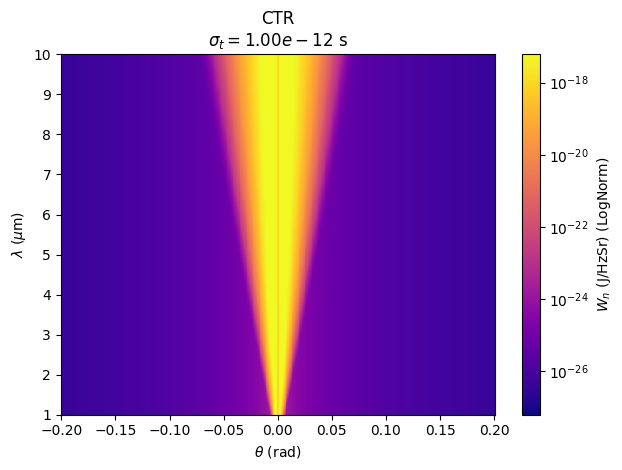

In [374]:
plot_ctr_spectrum(th, lam, Wn_2d_gaussian,vmin=vmin_gaussian, vmax=vmax_gaussian,sigma_t=sigma_t)


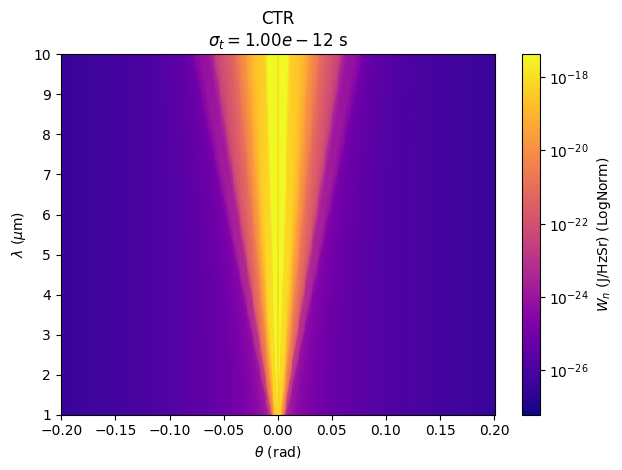

In [375]:
plot_ctr_spectrum(th, lam, Wn_2d_oam, vmin=vmin_oam, vmax=vmax_oam, sigma_t=sigma_t)

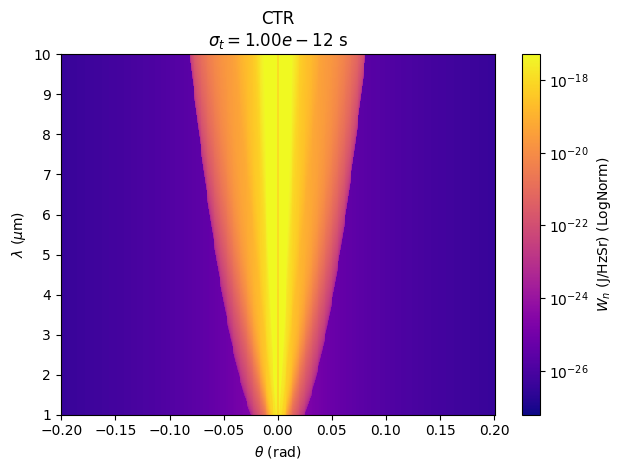

In [385]:
plot_ctr_spectrum(th, lam, Wn_2d_airy, vmin=vmin_airy, vmax=vmax_airy, sigma_t=sigma_t)